In [ ]:
import re
import ast
import unicodedata
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import spacy
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from rdflib import Graph, Namespace, RDF, RDFS, Literal

In [ ]:
NOTEBOOK_DIR = Path.cwd()              # debe ser /repo/Code
ROOT_DIR = NOTEBOOK_DIR.parent         # /repo

DATA_DIR = ROOT_DIR / "Data"
OUTPUT_DIR = ROOT_DIR / "Output"

ONTOLOGY_DIR = OUTPUT_DIR / "ontology"
CLUSTERS_DIR = OUTPUT_DIR / "clusters"
DEBUG_DIR = OUTPUT_DIR / "debug"

for d in [OUTPUT_DIR, ONTOLOGY_DIR, CLUSTERS_DIR, DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_DIR / "DicatJuanRana_Dataset.csv"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT_DIR:", ROOT_DIR)
print("CSV_PATH:", CSV_PATH)
print("CSV exists:", CSV_PATH.exists())

NOTEBOOK_DIR: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Code
ROOT_DIR: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology
CSV_PATH: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Data\DicatJuanRana_Dataset.csv
CSV exists: True


In [ ]:
USE_CLARIFIED_SENTENCES = True
DISTANCE_THRESHOLD = 1.4

In [ ]:
USE_CLARIFIED_SENTENCES = True
DISTANCE_THRESHOLD = 1.4

In [ ]:
nlp = spacy.load("es_core_news_lg")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2628.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "item"


def clean_text(text: str) -> str:
    text = str(text)
    text = text.replace("<br><br>", ". ")
    text = text.replace("<br>", ". ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def parse_sent_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value

    value = str(value).strip()

    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [clean_text(x) for x in parsed if str(x).strip()]
    except Exception:
        pass

    return [clean_text(value)] if value else []


def ensure_company_name(name: str) -> str:
    name = clean_text(name)
    if name.lower().startswith("compañía de "):
        return name
    return f"Compañía de {name}"


def is_valid_entity(name: str) -> bool:
    name = clean_text(name)

    if not name:
        return False

    # solo números o numeración tipo 1) 2. 3-
    if re.fullmatch(r"\d+[\)\.\-:]?", name):
        return False

    # empieza por número
    if re.match(r"^\d", name):
        return False

    # demasiado corto
    if len(name) < 2:
        return False

    # basura frecuente
    basura = {
        "y", "o", "e", "el", "la", "los", "las", "un", "una",
        "de", "del", "en", "por", "para", "con"
    }
    if name.lower() in basura:
        return False

    return True


def add_entity(entities, name, etype, source_text=""):
    name = clean_text(name)

    if not is_valid_entity(name):
        return

    entities[name]["name"] = name
    entities[name]["types"].append(etype)

    if source_text:
        entities[name]["examples"].append(source_text[:250])


def add_relation(raw_relations, subj, rel, obj, sent, year):
    subj = clean_text(subj)
    rel = clean_text(rel)
    obj = clean_text(obj)

    if not is_valid_entity(subj):
        return
    if not is_valid_entity(obj):
        return
    if not rel:
        return

    raw_relations.append({
        "year": year,
        "subject": subj,
        "raw_relation": rel,
        "object": obj,
        "sentence": sent
    })

In [ ]:
BIRTH_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+naci[oó]\s+en\s+(?P<obj>[A-ZÁÉÍÓÚÑ][^.,;]+)"
)

DEATH_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+muri[oó]\s+en\s+(?P<obj>[A-ZÁÉÍÓÚÑ][^.,;]+)"
)

BAUTIZED_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+fue bautizado(?:[^.;]*?)\s+en\s+(?P<obj>[A-ZÁÉÍÓÚÑ][^.,;]+)",
    re.IGNORECASE
)

SON_OF_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+fue hijo de\s+(?P<obj1>[A-ZÁÉÍÓÚÑ][^,;]+?)\s+e\s+(?P<obj2>[A-ZÁÉÍÓÚÑ][^.,;]+)",
    re.IGNORECASE
)

PART_OF_COMPANY_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+(?:formaba parte|aparece en la nómina|aparece en la nomina|figur[aó] entre cuyos miembros|estaba en|perteneci[oó])(?:[^.;]*?)compa[nñ]i?a de\s+(?P<obj>[A-ZÁÉÍÓÚÑ][^.,;]+)",
    re.IGNORECASE
)

THEATRICAL_RE = re.compile(
    r"(?P<subj>[A-ZÁÉÍÓÚÑ][^.,;]+?)\s+(?P<rel>actu[oó]|particip[oó]|represent[oó]|interpret[oó])(?:[^.;]{0,80}?)\s+(?:en|la|el)\s+(?P<obj>[A-ZÁÉÍÓÚÑ][^.;]+)",
    re.IGNORECASE
)

In [ ]:
def extract_entities_from_sentence(sent: str, entities):
    doc = nlp(sent)

    for ent in doc.ents:
        label = ent.label_
        text = clean_text(ent.text)

        if label in {"PER", "PERSON"}:
            add_entity(entities, text, "Persona", sent)
        elif label in {"LOC", "GPE"}:
            add_entity(entities, text, "Lugar", sent)
        elif label in {"ORG"}:
            add_entity(entities, text, "Organizacion", sent)

    for m in re.finditer(r"compa[nñ]i?a de\s+([A-ZÁÉÍÓÚÑ][^.,;]+)", sent, flags=re.IGNORECASE):
        company = ensure_company_name(m.group(1))
        add_entity(entities, company, "Compañía", sent)

In [ ]:
def expand_span(token, doc):
    left = min([t.i for t in token.subtree])
    right = max([t.i for t in token.subtree]) + 1
    text = doc[left:right].text
    return clean_text(text)

def detect_entities_left_of_verb(verb_token, doc):
    candidates = []
    for ent in doc.ents:
        if ent.end <= verb_token.i:
            ent_text = clean_text(ent.text)
            if is_valid_entity(ent_text):
                candidates.append(ent_text)

    # quedarse con la más cercana
    if candidates:
        return [candidates[-1]]
    return []

def detect_entities_right_of_verb(verb_token, doc):
    candidates = []
    for ent in doc.ents:
        if ent.start > verb_token.i:
            ent_text = clean_text(ent.text)
            if is_valid_entity(ent_text):
                candidates.append(ent_text)

    # quedarse con la primera más cercana
    if candidates:
        return [candidates[0]]
    return []

In [ ]:
def extract_relations_from_sentence(sent: str, raw_relations, entities, year: str):
    s = clean_text(sent)
    doc = nlp(s)

    # guardar entidades detectadas por spaCy
    ent_map = {}
    for ent in doc.ents:
        ent_text = clean_text(ent.text)
        if is_valid_entity(ent_text):
            ent_map[(ent.start, ent.end)] = ent_text
            add_entity(entities, ent_text, "Entidad", s)

    # recorrer verbos
    for token in doc:
        if token.pos_ != "VERB":
            continue

        subjects = []
        objects = []

        # sujeto sintáctico
        for child in token.children:
            if child.dep_ in {"nsubj", "nsubj:pass"}:
                subj_text = expand_span(child, doc)
                if is_valid_entity(subj_text):
                    subjects.append(subj_text)

            # objetos directos / indirectos / oblicuos
            if child.dep_ in {"obj", "iobj", "obl"}:
                obj_text = expand_span(child, doc)
                if is_valid_entity(obj_text):
                    objects.append(obj_text)

        # fallback: buscar entidades en la frase
        if not subjects:
            subjects = detect_entities_left_of_verb(token, doc)

        if not objects:
            objects = detect_entities_right_of_verb(token, doc)

        rel = token.lemma_.lower().strip()

        for subj in subjects:
            add_entity(entities, subj, "Entidad", s)

        for obj in objects:
            add_entity(entities, obj, "Entidad", s)

        for subj in subjects:
            for obj in objects:
                if subj != obj:
                    add_relation(raw_relations, subj, rel, obj, s, year)

In [ ]:
def remove_accents(text: str) -> str:
    text = unicodedata.normalize("NFKD", text)
    return "".join(c for c in text if not unicodedata.combining(c))


def normalize_relation(rel: str) -> str:
    rel = clean_text(rel).lower().strip()
    rel = remove_accents(rel)

    doc = nlp(rel)

    lemmas = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        lemmas.append(token.lemma_.lower())

    return " ".join(lemmas).strip()

In [ ]:
df = pd.read_csv(CSV_PATH, sep=";")

required_cols = {"year", "text", "sentences", "clarified_sentences"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Faltan columnas. Tengo: {df.columns.tolist()}")

df.head()

,year,text,sentences,clarified_sentences
0,0,"Aunque su verdadero nombre era Cosme Pérez, fu...","[""Aunque su verdadero nombre era Cosme Pérez, ...","[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,1617,"Según Cotarelo , a quien sigue Sáez Raposo , C...","['Según Cotarelo, a quien sigue Sáez Raposo, ...","['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,1621,Consta la lista de la compañía de Juan Bautist...,['Consta la lista de la compañía de Juan Bauti...,['Consta la lista de la compañía de Juan Bauti...
3,1624,Cosme Pérez aparece en la nómina de la compañí...,['Cosme Pérez aparece en la nómina de la compa...,['Cosme Pérez aparece en la nómina de la compa...
4,1634,"Según Cotarelo, Cosme Pérez pertenecía a la co...","['Según Cotarelo, Cosme Pérez pertenecía a la ...","['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [ ]:
entities = defaultdict(lambda: {"name": "", "types": [], "examples": []})
raw_relations = []

for _, row in df.iterrows():
    year = str(row["year"])

    if USE_CLARIFIED_SENTENCES:
        sentences = parse_sent_list(row["clarified_sentences"])
    else:
        sentences = parse_sent_list(row["sentences"])

    if not sentences:
        sentences = [clean_text(row["text"])]

    for sent in sentences:
        sent = clean_text(sent)
        if not sent:
            continue

        extract_entities_from_sentence(sent, entities)
        extract_relations_from_sentence(sent, raw_relations, entities, year)

raw_rel_df = pd.DataFrame(raw_relations).drop_duplicates()

if raw_rel_df.empty:
    raise ValueError("No se han extraído relaciones. Revisa regex o el contenido del CSV.")

raw_rel_df["normalized_relation"] = raw_rel_df["raw_relation"].apply(normalize_relation)

raw_rel_df.head(20)

,year,subject,raw_relation,object,sentence,normalized_relation
0,0,Cosme Pérez,nació en,Tudela de Duero (Valladolid),Aunque Cotarelo aventuró que pudo haber nacido...,nacer en
1,0,Cosme Pérez,hijo de,Damián Pérez,Cosme Pérez fue hijo de Damián Pérez e Isabel ...,ser hijo de
2,0,Cosme Pérez,hijo de,Isabel de Basto,Cosme Pérez fue hijo de Damián Pérez e Isabel ...,ser hijo de
3,0,cuando Juan Rana,participó,la representación de la comedia de Lope de Veg...,"Según F. Sáez Raposo, la primera aparición esc...",participar
4,0,el entremés se,representó,el Retiro durante la fiesta de San Juan de ese...,"Por su parte, según M. L. Lobato, el entremés ...",representar
5,0,se hizo en el Palacio de la Zarzuela con motiv...,representó,"un día de mucho frío, según se indica en el pr...","Según apunta M. L. Lobato, Antonio de Solís co...",representar
6,0,La pieza se,representó,palacio y M,La pieza se representó en palacio y M. L. Loba...,representar
7,0,Juan Rana también,actuó,"el entremés El ayo de Agustín Moreto, represen...","Según indica M. L. Lobato, Juan Rana también a...",actuar
8,0,esta loa se,representó,"muerte de Bernarda Ramírez, mujer de Sebastián...","Según Cotarelo, esta loa se representó ante lo...",representar
9,0,sugiere que el entremés se,representó,los últimos versos se hace mención del objeto ...,"M. L. Lobato, sin embargo, sugiere que el entr...",representar


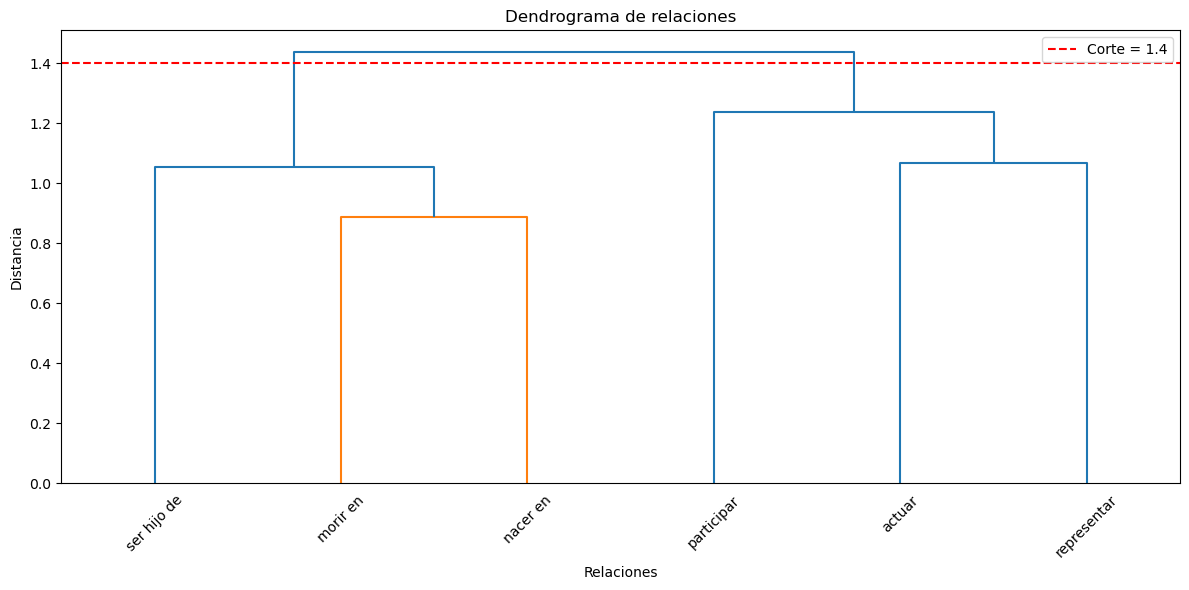

In [ ]:
relation_vocab = sorted(raw_rel_df["normalized_relation"].dropna().unique().tolist())
rel_embeddings = embedder.encode(relation_vocab)

Z = linkage(rel_embeddings, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=relation_vocab, leaf_rotation=45, leaf_font_size=10)
plt.axhline(y=DISTANCE_THRESHOLD, color="red", linestyle="--", label=f"Corte = {DISTANCE_THRESHOLD}")
plt.title("Dendrograma de relaciones")
plt.xlabel("Relaciones")
plt.ylabel("Distancia")
plt.legend()
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / "dendrogram_relations.png", dpi=200)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances


def get_cluster_representatives(relations, embeddings, cluster_labels):
    rows = []

    relations = np.array(relations)
    embeddings = np.array(embeddings)
    cluster_labels = np.array(cluster_labels)

    for cluster_id in sorted(set(cluster_labels)):
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_rels = relations[idx]
        cluster_embs = embeddings[idx]

        # matriz de distancias dentro del cluster
        dist_matrix = cosine_distances(cluster_embs)

        # suma de distancias por elemento
        dist_sums = dist_matrix.sum(axis=1)

        # medoide = relación más central
        medoid_local_idx = np.argmin(dist_sums)
        representative = cluster_rels[medoid_local_idx]

        rows.append({
            "cluster_id": cluster_id,
            "cluster_relations": list(cluster_rels),
            "representative_relation": representative
        })

    return pd.DataFrame(rows)

In [ ]:
cluster_labels = fcluster(Z, t=DISTANCE_THRESHOLD, criterion="distance")

relation_cluster_df = pd.DataFrame({
    "normalized_relation": relation_vocab,
    "cluster_id": cluster_labels
})

relation_cluster_df = relation_cluster_df.sort_values(["cluster_id", "normalized_relation"])
relation_cluster_df

,normalized_relation,cluster_id
1,morir en,1
2,nacer en,1
5,ser hijo de,1
0,actuar,2
3,participar,2
4,representar,2


In [ ]:
cluster_summary = get_cluster_representatives(
    relations=relation_vocab,
    embeddings=rel_embeddings,
    cluster_labels=cluster_labels
)

cluster_summary

,cluster_id,cluster_relations,representative_relation
0,1,"[morir en, nacer en, ser hijo de]",nacer en
1,2,"[actuar, participar, representar]",representar


In [ ]:
cluster_to_relation = dict(
    zip(cluster_summary["cluster_id"], cluster_summary["representative_relation"])
)

relation_cluster_df["ontology_relation"] = relation_cluster_df["cluster_id"].map(cluster_to_relation)

relation_cluster_df

,normalized_relation,cluster_id,ontology_relation
1,morir en,1,nacer en
2,nacer en,1,nacer en
5,ser hijo de,1,nacer en
0,actuar,2,representar
3,participar,2,representar
4,representar,2,representar


In [ ]:
cluster_view = relation_cluster_df.groupby("cluster_id").agg({
    "normalized_relation": lambda x: list(x),
    "ontology_relation": "first"
}).reset_index()

cluster_view

,cluster_id,normalized_relation,ontology_relation
0,1,"[morir en, nacer en, ser hijo de]",nacer en
1,2,"[actuar, participar, representar]",representar


In [ ]:
raw_rel_df = raw_rel_df.merge(
    relation_cluster_df[["normalized_relation", "cluster_id", "ontology_relation"]],
    on="normalized_relation",
    how="left"
)

raw_rel_df.head(20)

,year,subject,raw_relation,object,sentence,normalized_relation,cluster_id,ontology_relation
0,0,Cosme Pérez,nació en,Tudela de Duero (Valladolid),Aunque Cotarelo aventuró que pudo haber nacido...,nacer en,1,nacer en
1,0,Cosme Pérez,hijo de,Damián Pérez,Cosme Pérez fue hijo de Damián Pérez e Isabel ...,ser hijo de,1,nacer en
2,0,Cosme Pérez,hijo de,Isabel de Basto,Cosme Pérez fue hijo de Damián Pérez e Isabel ...,ser hijo de,1,nacer en
3,0,cuando Juan Rana,participó,la representación de la comedia de Lope de Veg...,"Según F. Sáez Raposo, la primera aparición esc...",participar,2,representar
4,0,el entremés se,representó,el Retiro durante la fiesta de San Juan de ese...,"Por su parte, según M. L. Lobato, el entremés ...",representar,2,representar
5,0,se hizo en el Palacio de la Zarzuela con motiv...,representó,"un día de mucho frío, según se indica en el pr...","Según apunta M. L. Lobato, Antonio de Solís co...",representar,2,representar
6,0,La pieza se,representó,palacio y M,La pieza se representó en palacio y M. L. Loba...,representar,2,representar
7,0,Juan Rana también,actuó,"el entremés El ayo de Agustín Moreto, represen...","Según indica M. L. Lobato, Juan Rana también a...",actuar,2,representar
8,0,esta loa se,representó,"muerte de Bernarda Ramírez, mujer de Sebastián...","Según Cotarelo, esta loa se representó ante lo...",representar,2,representar
9,0,sugiere que el entremés se,representó,los últimos versos se hace mención del objeto ...,"M. L. Lobato, sin embargo, sugiere que el entr...",representar,2,representar


In [ ]:
entity_contexts = defaultdict(list)

for _, row in raw_rel_df.iterrows():
    subj = row["subject"]
    obj = row["object"]
    rel = row["ontology_relation"]

    # contexto del sujeto
    entity_contexts[subj].append(f"subj_{rel}")
    entity_contexts[subj].append(f"rel_{rel}")
    entity_contexts[subj].append(f"with_{obj}")

    # contexto del objeto
    entity_contexts[obj].append(f"obj_{rel}")
    entity_contexts[obj].append(f"rel_{rel}")
    entity_contexts[obj].append(f"with_{subj}")

entity_context_rows = []
for ent, ctx in entity_contexts.items():
    context_text = " ".join(ctx)
    entity_context_rows.append({
        "entity": ent,
        "entity_id": slugify(ent),
        "context_text": context_text
    })

entity_context_df = pd.DataFrame(entity_context_rows)
entity_context_df.head(20)

,entity,entity_id,context_text
0,Cosme Pérez,cosme_perez,subj_nacer en rel_nacer en with_Tudela de Duer...
1,Tudela de Duero (Valladolid),tudela_de_duero_valladolid,obj_nacer en rel_nacer en with_Cosme Pérez
2,Damián Pérez,damian_perez,obj_nacer en rel_nacer en with_Cosme Pérez
3,Isabel de Basto,isabel_de_basto,obj_nacer en rel_nacer en with_Cosme Pérez
4,cuando Juan Rana,cuando_juan_rana,subj_representar rel_representar with_la repre...
5,la representación de la comedia de Lope de Veg...,la_representacion_de_la_comedia_de_lope_de_veg...,obj_representar rel_representar with_cuando Ju...
6,el entremés se,el_entremes_se,subj_representar rel_representar with_el Retir...
7,el Retiro durante la fiesta de San Juan de ese...,el_retiro_durante_la_fiesta_de_san_juan_de_ese...,obj_representar rel_representar with_el entrem...
8,se hizo en el Palacio de la Zarzuela con motiv...,se_hizo_en_el_palacio_de_la_zarzuela_con_motiv...,subj_representar rel_representar with_un día d...
9,"un día de mucho frío, según se indica en el pr...",un_dia_de_mucho_frio_segun_se_indica_en_el_pri...,obj_representar rel_representar with_se hizo e...


C:\Users\z99ro\AppData\Local\Temp\ipykernel_32792\3747055971.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


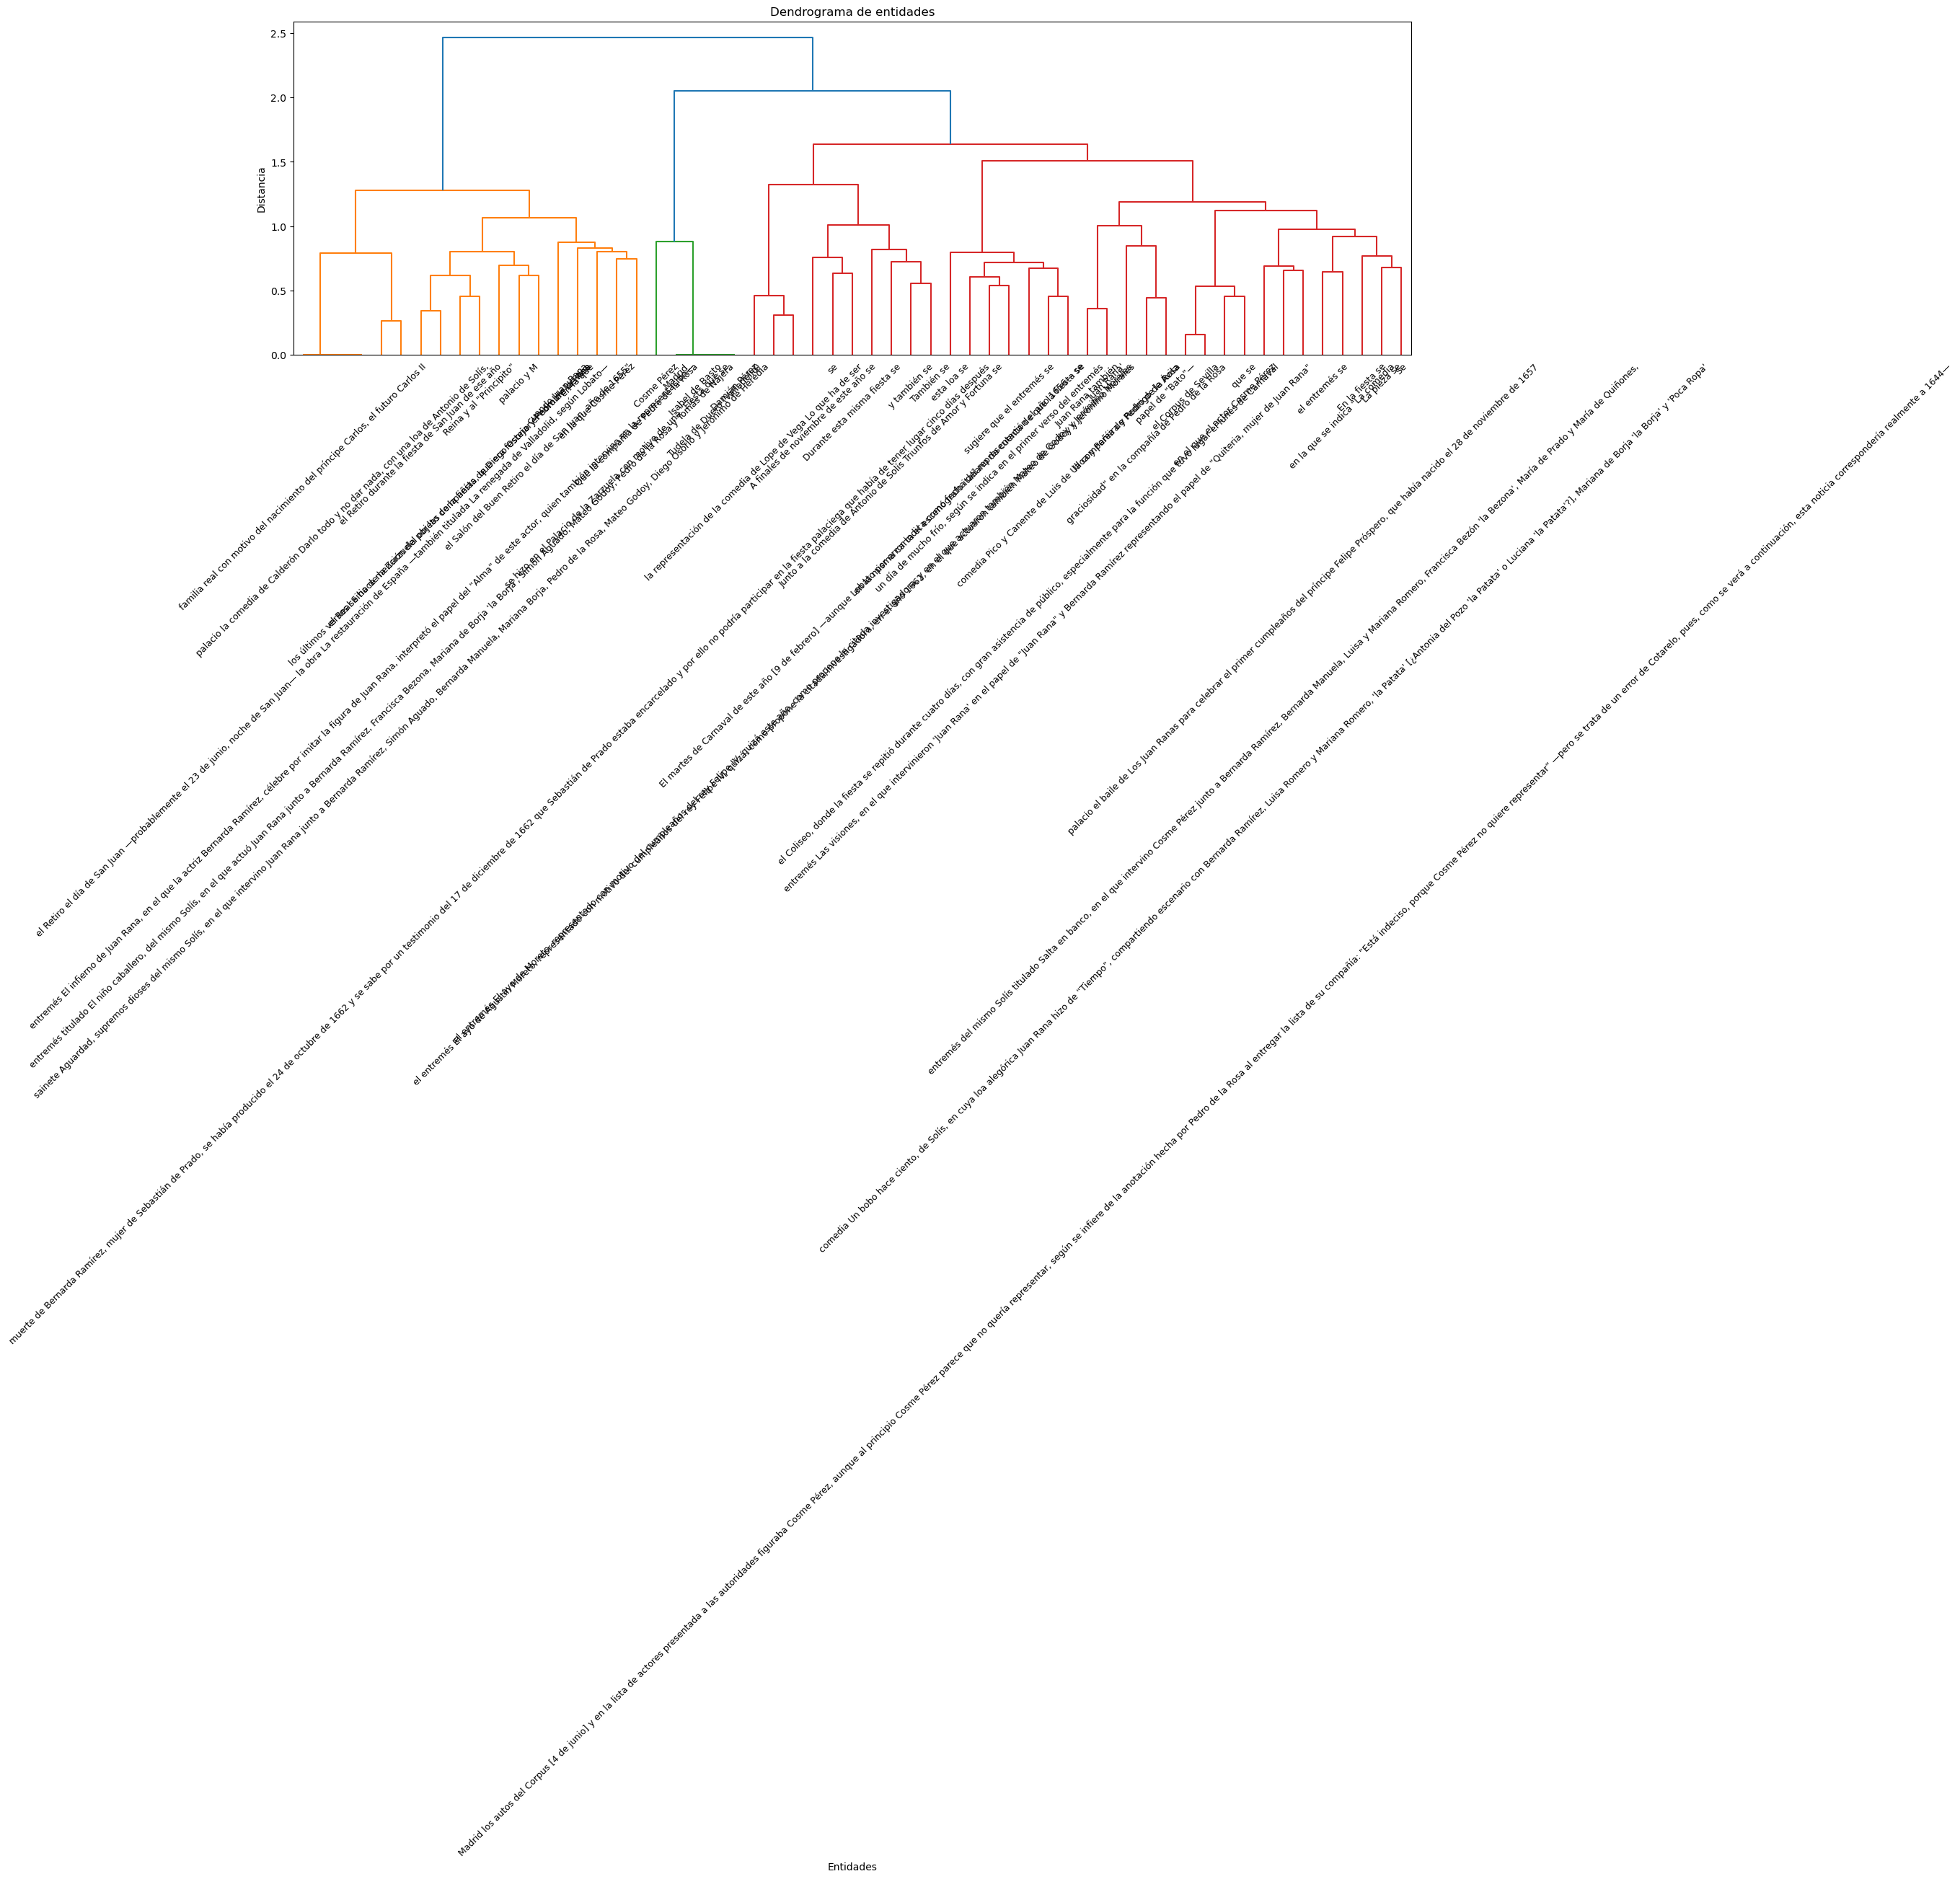

In [ ]:
entity_vocab = entity_context_df["entity"].tolist()
entity_texts = entity_context_df["context_text"].tolist()

entity_embeddings = embedder.encode(entity_texts)

Z_entities = linkage(entity_embeddings, method="ward")

plt.figure(figsize=(20, 6))
dendrogram(
    Z_entities,
    labels=entity_vocab,
    leaf_rotation=45,
    leaf_font_size=9
)
plt.title("Dendrograma de entidades")
plt.xlabel("Entidades")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / "dendrogram_entities.png", dpi=200)
plt.show()

In [ ]:
ENTITY_DISTANCE_THRESHOLD = 1.5

entity_cluster_labels = fcluster(
    Z_entities,
    t=ENTITY_DISTANCE_THRESHOLD,
    criterion="distance"
)

entity_cluster_df = pd.DataFrame({
    "entity": entity_vocab,
    "entity_id": [slugify(x) for x in entity_vocab],
    "entity_cluster_id": entity_cluster_labels
})

entity_cluster_df.head(20)

,entity,entity_id,entity_cluster_id
0,Cosme Pérez,cosme_perez,2
1,Tudela de Duero (Valladolid),tudela_de_duero_valladolid,2
2,Damián Pérez,damian_perez,2
3,Isabel de Basto,isabel_de_basto,2
4,cuando Juan Rana,cuando_juan_rana,1
5,la representación de la comedia de Lope de Veg...,la_representacion_de_la_comedia_de_lope_de_veg...,3
6,el entremés se,el_entremes_se,5
7,el Retiro durante la fiesta de San Juan de ese...,el_retiro_durante_la_fiesta_de_san_juan_de_ese...,1
8,se hizo en el Palacio de la Zarzuela con motiv...,se_hizo_en_el_palacio_de_la_zarzuela_con_motiv...,1
9,"un día de mucho frío, según se indica en el pr...",un_dia_de_mucho_frio_segun_se_indica_en_el_pri...,4


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

def get_entity_cluster_representatives(entities, embeddings, cluster_labels):
    rows = []

    entities = np.array(entities)
    embeddings = np.array(embeddings)
    cluster_labels = np.array(cluster_labels)

    for cluster_id in sorted(set(cluster_labels)):
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_entities = entities[idx]
        cluster_embs = embeddings[idx]

        dist_matrix = cosine_distances(cluster_embs)
        dist_sums = dist_matrix.sum(axis=1)
        medoid_local_idx = np.argmin(dist_sums)
        representative = cluster_entities[medoid_local_idx]

        rows.append({
            "entity_cluster_id": cluster_id,
            "cluster_entities": list(cluster_entities),
            "representative_entity": representative
        })

    return pd.DataFrame(rows)

entity_cluster_representatives = get_entity_cluster_representatives(
    entities=entity_vocab,
    embeddings=entity_embeddings,
    cluster_labels=entity_cluster_labels
)

entity_cluster_representatives

,entity_cluster_id,cluster_entities,representative_entity
0,1,"[cuando Juan Rana, el Retiro durante la fiesta...",el Real Sitio de la Zarzuela por las compañías...
1,2,"[Cosme Pérez, Tudela de Duero (Valladolid), Da...",Madrid
2,3,[la representación de la comedia de Lope de Ve...,También se
3,4,"[un día de mucho frío, según se indica en el p...",comedia Pico y Canente de Luis de Ulloa y Pere...
4,5,"[el entremés se, La pieza se, Juan Rana tambié...",que se


In [ ]:
def infer_cluster_type_auto(representative, cluster_entities):
    rep = str(representative).lower()

    # heurísticas léxicas mínimas, no de dominio experto fuerte
    if rep.startswith("compañía de") or any(str(x).lower().startswith("compañía de") for x in cluster_entities):
        return "Compañía"

    if any(tok in rep for tok in ["madrid", "sevilla", "toledo", "valladolid", "valencia", "lisboa", "zaragoza"]):
        return "Lugar"

    if any(tok in rep for tok in ["don ", "doña "]):
        return "Personaje"

    # si varias entidades tienen varias palabras con mayúsculas, suele tender a persona
    multiword = [x for x in cluster_entities if len(str(x).split()) >= 2]
    if len(multiword) >= max(1, len(cluster_entities) // 2):
        return "Persona"

    return "Entidad"

In [ ]:
entity_cluster_representatives["cluster_type"] = entity_cluster_representatives.apply(
    lambda row: infer_cluster_type_auto(
        representative=row["representative_entity"],
        cluster_entities=row["cluster_entities"]
    ),
    axis=1
)

entity_cluster_representatives

,entity_cluster_id,cluster_entities,representative_entity,cluster_type
0,1,"[cuando Juan Rana, el Retiro durante la fiesta...",el Real Sitio de la Zarzuela por las compañías...,Persona
1,2,"[Cosme Pérez, Tudela de Duero (Valladolid), Da...",Madrid,Lugar
2,3,[la representación de la comedia de Lope de Ve...,También se,Persona
3,4,"[un día de mucho frío, según se indica en el p...",comedia Pico y Canente de Luis de Ulloa y Pere...,Persona
4,5,"[el entremés se, La pieza se, Juan Rana tambié...",que se,Persona


In [ ]:
entity_cluster_df["entity_cluster_id"] = entity_cluster_df["entity_cluster_id"].astype("int64")
entity_cluster_representatives["entity_cluster_id"] = entity_cluster_representatives["entity_cluster_id"].astype("int64")

cluster_to_type = dict(
    zip(
        entity_cluster_representatives["entity_cluster_id"],
        entity_cluster_representatives["cluster_type"]
    )
)

entity_cluster_df["final_type"] = entity_cluster_df["entity_cluster_id"].map(cluster_to_type)

entities_df = pd.merge(
    entity_cluster_df,
    entity_cluster_representatives[["entity_cluster_id", "representative_entity"]],
    on="entity_cluster_id",
    how="left"
)

entities_df["confidence"] = 1.0
entities_df["votes"] = None

entities_df = entities_df[[
    "entity",
    "entity_id",
    "entity_cluster_id",
    "representative_entity",
    "final_type",
    "confidence",
    "votes"
]].sort_values(["final_type", "entity"])

entities_df.head(30)

,entity,entity_id,entity_cluster_id,representative_entity,final_type,confidence,votes
0,Cosme Pérez,cosme_perez,2,Madrid,Lugar,1.0,None
2,Damián Pérez,damian_perez,2,Madrid,Lugar,1.0,None
3,Isabel de Basto,isabel_de_basto,2,Madrid,Lugar,1.0,None
56,Madrid,madrid,2,Madrid,Lugar,1.0,None
1,Tudela de Duero (Valladolid),tudela_de_duero_valladolid,2,Madrid,Lugar,1.0,None
49,A finales de noviembre de este año se,a_finales_de_noviembre_de_este_ano_se,3,También se,Persona,1.0,None
30,Durante esta misma fiesta se,durante_esta_misma_fiesta_se,3,También se,Persona,1.0,None
32,El martes de Carnaval de este año [9 de febrer...,el_martes_de_carnaval_de_este_ano_9_de_febrero...,3,También se,Persona,1.0,None
37,En la fiesta se,en_la_fiesta_se,5,que se,Persona,1.0,None
12,Juan Rana también,juan_rana_tambien,5,que se,Persona,1.0,None


In [ ]:
entity_type_map = dict(zip(entities_df["entity"], entities_df["final_type"]))

ontology_rows = []
for _, row in raw_rel_df.iterrows():
    ontology_rows.append({
        "year": row["year"],
        "subject": row["subject"],
        "subject_type": entity_type_map.get(row["subject"], "Entidad"),
        "relation": row["ontology_relation"],
        "cluster_id": row["cluster_id"],
        "object": row["object"],
        "object_type": entity_type_map.get(row["object"], "Entidad"),
        "sentence": row["sentence"]
    })

ontology_df = pd.DataFrame(ontology_rows).drop_duplicates()
ontology_df.head(30)

,year,subject,subject_type,relation,cluster_id,object,object_type,sentence
0,0,Cosme Pérez,Lugar,nacer en,1,Tudela de Duero (Valladolid),Lugar,Aunque Cotarelo aventuró que pudo haber nacido...
1,0,Cosme Pérez,Lugar,nacer en,1,Damián Pérez,Lugar,Cosme Pérez fue hijo de Damián Pérez e Isabel ...
2,0,Cosme Pérez,Lugar,nacer en,1,Isabel de Basto,Lugar,Cosme Pérez fue hijo de Damián Pérez e Isabel ...
3,0,cuando Juan Rana,Persona,representar,2,la representación de la comedia de Lope de Veg...,Persona,"Según F. Sáez Raposo, la primera aparición esc..."
4,0,el entremés se,Persona,representar,2,el Retiro durante la fiesta de San Juan de ese...,Persona,"Por su parte, según M. L. Lobato, el entremés ..."
5,0,se hizo en el Palacio de la Zarzuela con motiv...,Persona,representar,2,"un día de mucho frío, según se indica en el pr...",Persona,"Según apunta M. L. Lobato, Antonio de Solís co..."
6,0,La pieza se,Persona,representar,2,palacio y M,Persona,La pieza se representó en palacio y M. L. Loba...
7,0,Juan Rana también,Persona,representar,2,"el entremés El ayo de Agustín Moreto, represen...",Persona,"Según indica M. L. Lobato, Juan Rana también a..."
8,0,esta loa se,Persona,representar,2,"muerte de Bernarda Ramírez, mujer de Sebastián...",Persona,"Según Cotarelo, esta loa se representó ante lo..."
9,0,sugiere que el entremés se,Persona,representar,2,los últimos versos se hace mención del objeto ...,Persona,"M. L. Lobato, sin embargo, sugiere que el entr..."


In [ ]:
raw_rel_df.to_csv(DEBUG_DIR / "raw_relations.csv", index=False, encoding="utf-8")

relation_cluster_df.to_csv(CLUSTERS_DIR / "relation_clusters.csv", index=False, encoding="utf-8")
cluster_view.to_csv(CLUSTERS_DIR / "relation_cluster_summary.csv", index=False, encoding="utf-8")

entity_context_df.to_csv(DEBUG_DIR / "entity_contexts.csv", index=False, encoding="utf-8")
entity_cluster_df.to_csv(CLUSTERS_DIR / "entity_clusters.csv", index=False, encoding="utf-8")
entity_cluster_representatives.to_csv(CLUSTERS_DIR / "entity_cluster_representatives.csv", index=False, encoding="utf-8")

entities_df.to_csv(ONTOLOGY_DIR / "entities_typed.csv", index=False, encoding="utf-8")
ontology_df.to_csv(ONTOLOGY_DIR / "ontology_triples.csv", index=False, encoding="utf-8")

print("Guardado completado.")
print("DEBUG_DIR:", DEBUG_DIR)
print("CLUSTERS_DIR:", CLUSTERS_DIR)
print("ONTOLOGY_DIR:", ONTOLOGY_DIR)

Guardado completado.
DEBUG_DIR: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Output\debug
CLUSTERS_DIR: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Output\clusters
ONTOLOGY_DIR: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Output\ontology


In [ ]:
g = Graph()
EX = Namespace("http://example.org/dicat/")
g.bind("ex", EX)

classes = ["Persona", "Lugar", "Compañía", "Obra", "Personaje", "Organizacion", "Entidad"]
for cls in classes:
    g.add((EX[slugify(cls)], RDF.type, RDFS.Class))
    g.add((EX[slugify(cls)], RDFS.label, Literal(cls)))

for _, row in entities_df.iterrows():
    ent_uri = EX[row["entity_id"]]
    cls_uri = EX[slugify(row["final_type"])]
    g.add((ent_uri, RDF.type, cls_uri))
    g.add((ent_uri, RDFS.label, Literal(row["entity"])))

for _, row in ontology_df.iterrows():
    s_uri = EX[slugify(row["subject"])]
    p_uri = EX[slugify(row["relation"])]
    o_uri = EX[slugify(row["object"])]
    g.add((s_uri, p_uri, o_uri))

ttl_path = ONTOLOGY_DIR / "ontology.ttl"
g.serialize(destination=str(ttl_path), format="turtle")

print("Ontología RDF guardada en:", ttl_path)

Ontología RDF guardada en: c:\Users\z99ro\OneDrive - UNIR\UNIR\TFM\Git\TFM_Ontology\Output\ontology\ontology.ttl


In [ ]:
print("=== RESUMEN ===")
print("Filas del CSV:", len(df))
print("Relaciones extraídas:", len(raw_rel_df))
print("Clusters de relaciones:", relation_cluster_df["cluster_id"].nunique())
print("Clusters de entidades:", entity_cluster_df["entity_cluster_id"].nunique())
print("Entidades tipadas:", len(entities_df))
print("Tripletas ontológicas:", len(ontology_df))

print("\n=== CLUSTERS DE RELACIONES ===")
display(cluster_view)

print("\n=== CLUSTERS DE ENTIDADES ===")
display(entity_cluster_representatives)

print("\n=== ENTIDADES ===")
display(entities_df.head(20))

print("\n=== ONTOLOGÍA ===")
display(ontology_df.head(20))

=== RESUMEN ===
Filas del CSV: 38
Relaciones extraídas: 32
Clusters de relaciones: 2
Clusters de entidades: 5
Entidades tipadas: 57
Tripletas ontológicas: 32

=== CLUSTERS DE RELACIONES ===


,cluster_id,normalized_relation,ontology_relation
0,1,"[morir en, nacer en, ser hijo de]",nacer en
1,2,"[actuar, participar, representar]",representar



=== CLUSTERS DE ENTIDADES ===


,entity_cluster_id,cluster_entities,representative_entity,cluster_type
0,1,"[cuando Juan Rana, el Retiro durante la fiesta...",el Real Sitio de la Zarzuela por las compañías...,Persona
1,2,"[Cosme Pérez, Tudela de Duero (Valladolid), Da...",Madrid,Lugar
2,3,[la representación de la comedia de Lope de Ve...,También se,Persona
3,4,"[un día de mucho frío, según se indica en el p...",comedia Pico y Canente de Luis de Ulloa y Pere...,Persona
4,5,"[el entremés se, La pieza se, Juan Rana tambié...",que se,Persona



=== ENTIDADES ===


,entity,entity_id,entity_cluster_id,representative_entity,final_type,confidence,votes
0,Cosme Pérez,cosme_perez,2,Madrid,Lugar,1.0,None
2,Damián Pérez,damian_perez,2,Madrid,Lugar,1.0,None
3,Isabel de Basto,isabel_de_basto,2,Madrid,Lugar,1.0,None
56,Madrid,madrid,2,Madrid,Lugar,1.0,None
1,Tudela de Duero (Valladolid),tudela_de_duero_valladolid,2,Madrid,Lugar,1.0,None
49,A finales de noviembre de este año se,a_finales_de_noviembre_de_este_ano_se,3,También se,Persona,1.0,None
30,Durante esta misma fiesta se,durante_esta_misma_fiesta_se,3,También se,Persona,1.0,None
32,El martes de Carnaval de este año [9 de febrer...,el_martes_de_carnaval_de_este_ano_9_de_febrero...,3,También se,Persona,1.0,None
37,En la fiesta se,en_la_fiesta_se,5,que se,Persona,1.0,None
12,Juan Rana también,juan_rana_tambien,5,que se,Persona,1.0,None



=== ONTOLOGÍA ===


,year,subject,subject_type,relation,cluster_id,object,object_type,sentence
0,0,Cosme Pérez,Lugar,nacer en,1,Tudela de Duero (Valladolid),Lugar,Aunque Cotarelo aventuró que pudo haber nacido...
1,0,Cosme Pérez,Lugar,nacer en,1,Damián Pérez,Lugar,Cosme Pérez fue hijo de Damián Pérez e Isabel ...
2,0,Cosme Pérez,Lugar,nacer en,1,Isabel de Basto,Lugar,Cosme Pérez fue hijo de Damián Pérez e Isabel ...
3,0,cuando Juan Rana,Persona,representar,2,la representación de la comedia de Lope de Veg...,Persona,"Según F. Sáez Raposo, la primera aparición esc..."
4,0,el entremés se,Persona,representar,2,el Retiro durante la fiesta de San Juan de ese...,Persona,"Por su parte, según M. L. Lobato, el entremés ..."
5,0,se hizo en el Palacio de la Zarzuela con motiv...,Persona,representar,2,"un día de mucho frío, según se indica en el pr...",Persona,"Según apunta M. L. Lobato, Antonio de Solís co..."
6,0,La pieza se,Persona,representar,2,palacio y M,Persona,La pieza se representó en palacio y M. L. Loba...
7,0,Juan Rana también,Persona,representar,2,"el entremés El ayo de Agustín Moreto, represen...",Persona,"Según indica M. L. Lobato, Juan Rana también a..."
8,0,esta loa se,Persona,representar,2,"muerte de Bernarda Ramírez, mujer de Sebastián...",Persona,"Según Cotarelo, esta loa se representó ante lo..."
9,0,sugiere que el entremés se,Persona,representar,2,los últimos versos se hace mención del objeto ...,Persona,"M. L. Lobato, sin embargo, sugiere que el entr..."
